(fin-edu:investing:mpt-capm:uncertainty)=
# Uncertainty in MPT and CAPM Models

In this section, the sensitivity of the results of MPT and CAPM models w.r.t. variation of expected returna and variance of the individual assets is discussed.

In [9]:
"""
Modern Portfolio Theory
Example with a 3-asset portfolio

"""

import numpy as np
from scipy.optimize import minimize
from functools import partial

import matplotlib.pyplot as plt


(fin-edu:investing:mpt-capm:mpt)=
## Modern Portfolio Theory

<!-- (fin-edu:investing:mpt-capm:assets)= -->
**Assets.** There are $N$ available assets, whose $\mathbf{r} = ( r_i )$ return over the period of interest has

* expected value $\boldsymbol\mu = ( \mu_i ) = \mathbb{E}(r_i)$, 
* covariance matrix $\boldsymbol{\sigma}^2 = ( \sigma^2_{ij} ) = \mathbb{E}[ (r_i-\mu_i) (r_j - \mu_j)]$.


In [10]:
#> Dictionary collecting different assets for building portfolio
ptfs = {}

#> 1. Two-asset portfolio
# Here, un-correlated assets, r12 = 0
#> Expected returns and covariance
mu1, mu2 =  5., 10.
si1, si2 =  6., 15.
r12  = .0

mu = np.array([mu1, mu2])
si = np.array([
    [      si1**2, si1*si2*r12],
    [ si1*si2*r12,      si2**2]
])

ptfs['risky'] = { 'mu': mu, 'si': si, 'marker': 'x' }
ptfs['risky']['w/o risk-free'] = None

#> 2. Three-asset portfolio
# The same as the two-asset portfolio above, with an extra risk-free asset
# (risk-free = zero variance, si3 = .0)
#> Expected returns and covariance
mu1, mu2, mu3 = 5., 10.,  3.
si1, si2, si3 = 6., 15.,  0.
r12, r13, r23 = .0, .0, .0

mu = np.array([mu1, mu2, mu3])
si = np.array([
    [      si1**2, si1*si2*r12, si1*si3*r13],
    [ si1*si2*r12,      si2**2, si2*si3*r23],
    [ si1*si3*r13, si2*si3*r23,      si3**2]
])

ptfs['with risk-free'] = { 'mu': mu, 'si': si, 'marker': 's' }
ptfs['with risk-free']['w/o risk-free'] = 'risky'



**Useful arrays and functions.** Functions to be used in the optimization are defined here. The optimization process aims at finding the asset allocation with minimum variance of the return, given the expected value of the return. 

In [11]:
# Find min, max returns for plots
mu_v = np.concatenate( [ i['mu'] for k,i in ptfs.items() ] )

min_mu = np.min(mu_v) 
max_mu = np.max(mu_v) + 2.0

#> MPT
# An optimization problem is solved for a set of desired return to find the efficient
# frontier of a portfolio, under the assumptions of MPT

#> Array of desired returns, between min and max return of single assets
# des_ret_v = np.linspace(min_mu, max_mu, 30)

#> Constraints
def eq_desired_return(x, mu, desired_ret):
    return np.sum( x * mu ) - desired_ret

def eq_weight_sum(x):
    return np.sum(x) - 1

#> Objective function
def ptf_var(x, sigma):
    return x.T @ sigma @ x

(fin-edu:investing:mpt-capm:capm-leverage-short)=
## Efficient frontier and CAPM with possibility of leverage and short-selling


In [107]:
method = 'linear-system'

for kptf, ptf in ptfs.items():

    n_assets = len(ptf['mu'])

    ptf['wmat'] = []
    ptf['min_sig'] = []
    ptf['lagr_ptf_exp_ret'] = []
    ptf['des_ret'] = np.linspace(np.min(ptf['mu']) - 2. , np.max(ptf['mu']) + 2., 30)
    ptf['delta_wmat'] = []

    for desired_ret in ptf['des_ret']:

        if method == 'optimization':
            #> Constraints (just comment if you don't want some)
            eq_cons = [
                {'type':   'eq', 'fun': partial(eq_desired_return, mu=ptf['mu'], desired_ret=desired_ret)},
                {'type':   'eq', 'fun': eq_weight_sum},     # sum(w) = 1 (fully invested)
            ]
            # eq_cons += [ {'type': 'ineq', 'fun': lambda x:   x[i]} for i in np.arange(n_assets) ]
            # eq_cons += [ {'type': 'ineq', 'fun': lambda x: 1-x[i]} for i in np.arange(n_assets) ]
    
            cost_fun = partial(ptf_var, sigma=ptf['si'])
    
            x0 = np.zeros(n_assets); x0[0] = 1  #  np.ones(3) / 3.
            res = minimize(cost_fun, x0, constraints=eq_cons,)

            ptf_si = np.sqrt(res.x.T @ ptf['si'] @ res.x)
            ptf_mu = np.sum(res.x * ptf['mu'])
    
            #> Store weights and min variance, for the desired expected return
            ptf['wmat'] += [ res.x ]
            ptf['min_sig'] += [ ptf_si ]
            
        elif method == 'linear-system':
            mu = np.zeros((n_assets,1)); mu[:,0] = ptf['mu']
            A = np.block([
                [ ptf['si'], -mu, -np.ones((n_assets,1)) ],
                [ -mu.T                  , np.zeros((1, 2)) ],
                [ -np.ones((1, n_assets)), np.zeros((1, 2)) ],
            ])
            b = np.zeros((n_assets+2,1))
            b[-2,0] = -desired_ret
            b[-1,0] = -1

            x = np.linalg.solve(A, b)
            w = x[:-2,0]
            a, b = x[-2,0], x[-1,0]
    
            ptf_si = np.sqrt(w.T @ ptf['si'] @ w)
            ptf_mu = np.sum(w * ptf['mu'])
            
            #> Store weights and min variance, for the desired expected return
            ptf['wmat'] += [ w ]
            ptf['min_sig'] += [ ptf_si ]
            ptf['lagr_ptf_exp_ret'] += [ -2 * a ]

            #> Uncertainty
            wT = np.zeros((1,n_assets));  wT[0,:] = w.copy()
            delta_b = np.block([
                [ 2 * a * np.eye(n_assets)], [-wT], [np.zeros((1, n_assets))]
            ])
            delta_w = np.linalg.solve( A, delta_b )[:-2,:]

            ptf['delta_wmat'] += [ delta_w ]
            
        # print(f"Desired Return: {desired_ret}, res: {res.x}")

    ptf['delta_wmat'] = np.array(ptf['delta_wmat'])


In [108]:
for kptf, ptf in ptfs.items():
    print(np.shape(ptf['delta_wmat']))

(30, 2, 2)
(30, 3, 3)


**Plots**

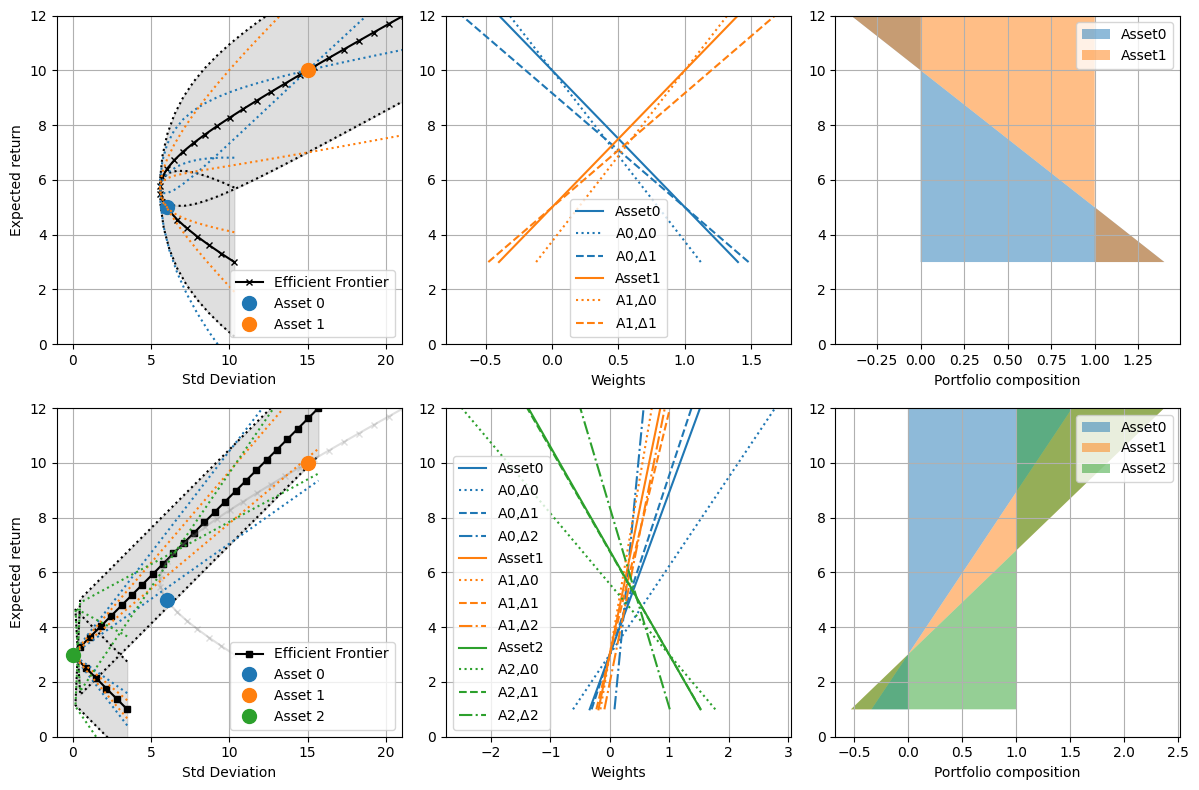

In [124]:
#> Initialize plot
fig, ax = plt.subplots(len(ptfs), 3, figsize=(12, 8))

cmap = plt.get_cmap('tab10')

nptf = 0
for kptf, ptf in ptfs.items():

    #>
    si = ptf["si"]
    mu = ptf["mu"]

    #> Weights
    wmat = np.array(ptf['wmat'])

    # print(ptf['des_ret'])
    
    n_assets = len(ptf['mu'])
    delta_asset_exp_ret = 1. * np.ones(n_assets)  # hardcoded so far (delta exp ret = 1 for all the assets)

    n_points = len(ptf['des_ret'])

    # print(wmat)
    # print(" ******** ")
    # print(ptf['lagr_ptf_exp_ret'])
    # print(np.sum( wmat[0,:] * delta_asset_exp_ret))
    # print(" ++++++++ ")
    
    delta_ptf_exp_ret = np.array([
        ptf['lagr_ptf_exp_ret'][i] * np.sum( wmat[i,:] * delta_asset_exp_ret ) / ( 2. * ptf['min_sig'][i] )
        for i in np.arange(n_points)
    ])

    delta_ptf_exp_ret_assets = np.array([ ptf['lagr_ptf_exp_ret'] * wmat[:,i_row] / ( 2. * np.array(ptf['min_sig']) ) for i_row in np.arange(np.shape(wmat)[1]) ])
    
    # for kptf, ptf in ptfs.items():
    ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret'], ptf['marker']+'-', label='Efficient Frontier', color='black', markersize=5,)
    ax[nptf,0].fill_between(
        ptf['min_sig'], 
        ptf['des_ret']-delta_ptf_exp_ret, 
        ptf['des_ret']+delta_ptf_exp_ret, alpha = .25, color='grey')
    ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret']-delta_ptf_exp_ret, ':', color='black', markersize=5,)
    ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret']+delta_ptf_exp_ret, ':', color='black', markersize=5,)
    
    if ( not ptf['w/o risk-free'] == None ):
        ptf_rf = ptfs[ptf['w/o risk-free']]
        ax[nptf,0].plot(ptf_rf['min_sig'], ptf_rf['des_ret'], ptf_rf['marker']+'-', color='grey', markersize=5, alpha=.25)
        

    for iass in np.arange(len(mu)):
        ax[nptf,0].plot(si[iass,iass]**.5, mu[iass], 'o', markersize=10, label=f'Asset {iass}')
        ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret']-delta_ptf_exp_ret_assets[iass,:], ':', color=cmap(iass%10), markersize=5,)
        ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret']+delta_ptf_exp_ret_assets[iass,:], ':', color=cmap(iass%10), markersize=5,)
    
    ax[nptf,0].set_xlim([-1, 21])
    ax[nptf,0].set_ylim([ 0, 12])
    # ax[nptf,0].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,0].set_xlabel("Std Deviation")
    ax[nptf,0].set_ylabel("Expected return")
    ax[nptf,0].grid()
    ax[nptf,0].legend()

    #> Asset Weights
    for i in np.arange(np.shape(wmat)[1]):
        ax[nptf,1].plot(wmat[:,i], ptf['des_ret'], color=cmap(i%10), label=f"Asset{i}")

        #> Uncertainty for each delta mu[i] = 1
        linestyle_uncertainty = [ 'dotted', 'dashed', 'dashdot' ]
        for i_w in np.arange(n_assets):
            ax[nptf,1].plot(wmat[:,i] + ptf['delta_wmat'][:, i, i_w], ptf['des_ret'], linestyle=linestyle_uncertainty[i_w], color=cmap(i%10), label=f"A{i},$\Delta${i_w}")
            


    
    ax[nptf,1].set_xlabel("Weights")
    ax[nptf,1].legend(); ax[nptf,1].grid()
    # ax[nptf,1].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,1].set_ylim([ 0, 12])

    
    

    #> Stacked - with expected return on y
    cum = np.zeros((np.shape(wmat)[0], np.shape(wmat)[1]+1))

    for i in np.arange(1, np.shape(cum)[1]):
        cum[:,i] = cum[:,i-1] + wmat[:,i-1]

    for i in np.arange(1, np.shape(cum)[1]):
        ax[nptf,2].fill_betweenx(ptf['des_ret'], cum[:,i-1], cum[:,i], label=f"Asset{i-1}", alpha = .5)

    ax[nptf,2].legend(); ax[nptf,2].grid()  # loc='upper right'
    ax[nptf,2].set_xlabel('Portfolio composition')
    # ax[nptf,2].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,2].set_ylim([ 0, 12])

    nptf += 1

fig.tight_layout()
plt.show()